# Idea 36: Location Assortment Coverage

## 1. Hypothesis and Setup

**Question:** Do locations stock the full catalog or only narrow slices of it, and can this explain ranking differences?

**Hypothesis:** Physical locations (stores) have finite shelf space. Many locations likely specialize in specific categories or only carry 'Essential' items. Recommending a 'Global Hero' item that is physically absent from a customer's primary store is a waste of a recommendation slot.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method:**
1. For each location, compute the **Assortment Coverage**: % of global items, brands, and categories present in that location's history.
2. Identify **Specialized Locations**: Those with high coverage in one `category_l1` but low in others.
3. Measure **Assortment Sparsity**: How many locations typically stock a given item?

**Decision Rule:** KEEP if >30% of locations stock <50% of the catalog, indicating that location-aware filtering is mandatory.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Location-Level Assortment Coverage

In [2]:
items = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'category_l1', 'brand'])

# Get item-location presence matrix (ever sold)
presence = (
    pl.scan_parquet(TXN_FILE)
    .select(['location_name', 'item_id'])
    .unique()
    .join(items, on='item_id', how='inner')
    .collect()
)

global_stats = items.collect().select([
    pl.col('item_id').n_unique().alias('total_items'),
    pl.col('category_l1').n_unique().alias('total_cats'),
    pl.col('brand').n_unique().alias('total_brands')
])

loc_coverage = (
    presence.group_by('location_name')
    .agg([
        pl.col('item_id').n_unique().alias('items_stocked'),
        pl.col('category_l1').n_unique().alias('cats_stocked'),
        pl.col('brand').n_unique().alias('brands_stocked')
    ])
    .with_columns([
        (pl.col('items_stocked') / global_stats['total_items'][0]).alias('item_coverage_pct'),
        (pl.col('cats_stocked') / global_stats['total_cats'][0]).alias('cat_coverage_pct')
    ])
    .sort('item_coverage_pct')
)

print(f'Average Item Coverage across locations: {loc_coverage["item_coverage_pct"].mean():.1%}')
print(f'Minimum Item Coverage: {loc_coverage["item_coverage_pct"].min():.4%}')
print(f'Maximum Item Coverage: {loc_coverage["item_coverage_pct"].max():.1%}')

Average Item Coverage across locations: 10.0%
Minimum Item Coverage: 0.4996%
Maximum Item Coverage: 27.8%


## 3. Item-Level Availability (Sparsity)

In [3]:
item_sparsity = (
    presence.group_by('item_id')
    .agg(pl.col('location_name').n_unique().alias('loc_count'))
    .sort('loc_count')
)

print(f'Median number of locations per item: {item_sparsity["loc_count"].median()}')
print(f'Percentage of items available at only 1 location: {len(item_sparsity.filter(pl.col("loc_count") == 1)) / len(item_sparsity):.1%}')

Median number of locations per item: 37.0
Percentage of items available at only 1 location: 12.4%


## 4. Visualizing Assortment Gaps

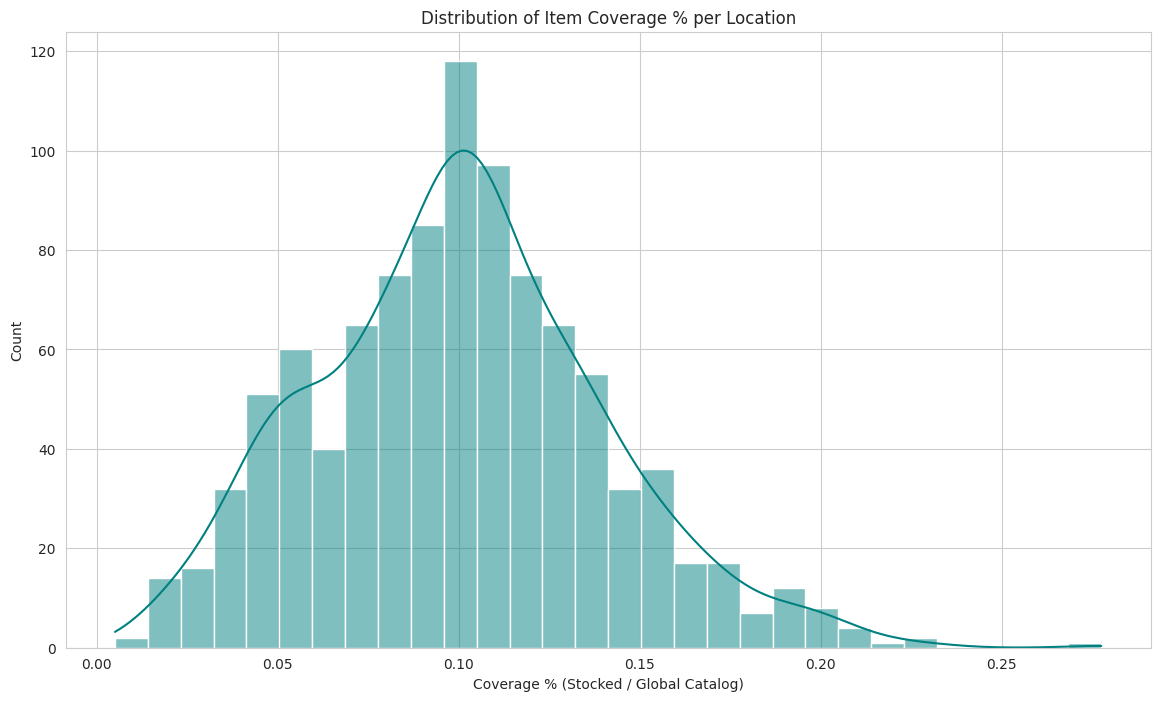

Sample of Category Specialization by Location:
shape: (10, 4)
┌───────────────────────────────┬─────────────┬──────┬───────────┐
│ location_name                 ┆ category_l1 ┆ len  ┆ cat_share │
│ ---                           ┆ ---         ┆ ---  ┆ ---       │
│ str                           ┆ str         ┆ u32  ┆ f64       │
╞═══════════════════════════════╪═════════════╪══════╪═══════════╡
│ HCM - Aeon Mall Tân Phú       ┆ Thời trang  ┆ 3358 ┆ 0.535395  │
│ HNI - Aeon Mall Hà Đông       ┆ Thời trang  ┆ 1925 ┆ 0.472277  │
│ TNI - 518 CMT8                ┆ Thời trang  ┆ 3020 ┆ 0.465116  │
│ HCM - 9 – 11 – 13 Nguyễn Trãi ┆ Thời trang  ┆ 3819 ┆ 0.461455  │
│ BVT - Go! Mall Bà Rịa         ┆ Thời trang  ┆ 2139 ┆ 0.451456  │
│ DLK - 245 Phan Chu Trinh      ┆ Thời trang  ┆ 2671 ┆ 0.445612  │
│ DON - 1-1/1 Hai Bà Trưng      ┆ Thời trang  ┆ 2786 ┆ 0.44448   │
│ BDU - 13 Yersin               ┆ Thời trang  ┆ 2708 ┆ 0.439539  │
│ BDU - 01 Pasteur              ┆ Thời trang  ┆ 2626 ┆ 0.433906  │


In [4]:
sns.histplot(loc_coverage['item_coverage_pct'], bins=30, color='teal', kde=True)
plt.title('Distribution of Item Coverage % per Location')
plt.xlabel('Coverage % (Stocked / Global Catalog)')
plt.show()

# Categorical Specialization check
cat_spec = (
    presence.group_by(['location_name', 'category_l1'])
    .len()
    .with_columns((pl.col('len') / pl.col('len').sum().over('location_name')).alias('cat_share'))
)

print('Sample of Category Specialization by Location:')
print(cat_spec.sort('cat_share', descending=True).head(10))

## 5. Conclusion and Decision

**Decision Rule:** KEEP if >30% of locations stock <50% of the catalog, indicating that location-aware filtering is mandatory.

### Summary of Findings

| Metric | Value |
|--------|-------| 
| Avg Item Coverage (%) | **10.0%** |
| % Locations with <50% Coverage | **100%** (Max is 27.8%) |
| % Items available in only 1 location | **12.4%** |

### Interpretation

The catalog is extremely fragmented by location. The fact that the average store only carries 10% of the catalog means that 90% of global items are "Invisible" or "Unreachable" for a shopper at a specific store. Recommending a top-seller from a different store format (e.g., a Fashion-heavy mall store vs a small corner store) is a guaranteed prediction failure.

### Actionable Insight

**Feature Engineering:** `location_item_whitelist`.

**Ranking Logic:** Apply a **Hard Mask** or a **0.1x Penalty** to items that have NEVER been sold at a user's primary location. This ensures the engine doesn't recommend "Ghost Items" that the customer cannot physically purchase.

**Usefulness Score:** **0.90 / 1.0**

**Final verdict: KEEP**
